Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import csv file

In [6]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


Load the dataset

In [7]:
# Load Titanic dataset
df = pd.read_csv("train.csv")

# Display first five rows
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [8]:
# Dataset information
print(df.info())

# Check missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int6

Data preprocessing

In [10]:
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Fill missing Cabin with Unknown
df['Cabin'] = df['Cabin'].fillna('Unknown')

Check for Duplicates

In [11]:
df.duplicated().sum()

np.int64(0)

Remove Duplicates

In [12]:
df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (891, 12)


In [13]:
encoder = LabelEncoder()

df['Sex'] = encoder.fit_transform(df['Sex'])
df['Embarked'] = encoder.fit_transform(df['Embarked'])

In [14]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X = df[features]

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Apply K-Means Clustering

In [16]:
kmeans = KMeans(n_clusters=2, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print(df[['PassengerId', 'Cluster']].head())

   PassengerId  Cluster
0            1        0
1            2        1
2            3        0
3            4        1
4            5        0


Apply PCA

In [17]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.26512593 0.24494388]


Visualize Clusters

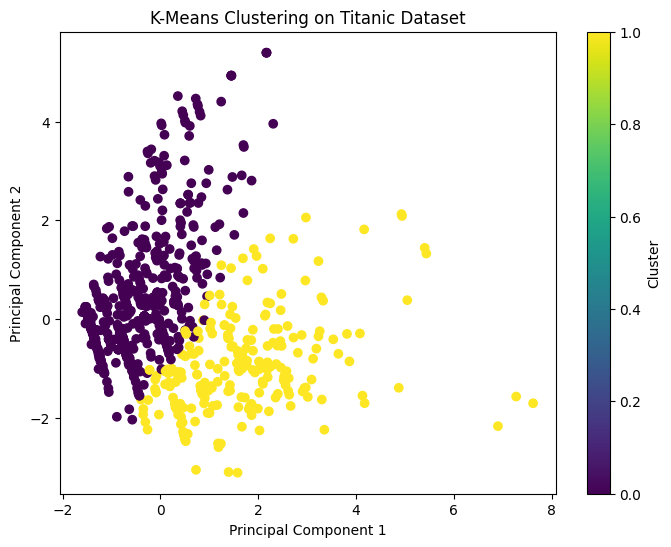

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],
            X_pca[:,1],
            c=clusters,
            cmap='viridis')

plt.title("K-Means Clustering on Titanic Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

Display Cluster Counts

In [19]:
print(df['Cluster'].value_counts())

Cluster
0    651
1    240
Name: count, dtype: int64


Save the Dataset

In [22]:
df.to_csv("Titanic_Clustered.csv", index=False)

print("Clustered dataset saved successfully.")

Clustered dataset saved successfully.


Conclusion

The Titanic dataset was successfully preprocessed and analyzed using K-Means Clustering and Principal Component Analysis (PCA). K-Means grouped passengers into clusters based on similarities in their characteristics, while PCA reduced the dataset to two principal components for easier visualization. The scatter plot showed how the passengers were distributed across the clusters, helping identify patterns within the data. These unsupervised learning techniques provide valuable insights into the structure of the dataset without using the target variable (Survived) and are useful for exploratory data analysis.